In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
from astropy.table import Table
from astropy.io import fits
import seaborn as sns
from matplotlib.animation import PillowWriter
import matplotlib as mpl
from matplotlib.ticker import FormatStrFormatter
from matplotlib.colors import TwoSlopeNorm
import matplotlib.colors as mcolors
import random

params = {
   'axes.labelsize': 20,
   'font.size': 15,
   'legend.fontsize': 14,
   'xtick.minor.visible': True,
   'ytick.minor.visible': True,
   'xtick.labelsize': 15,
   'ytick.labelsize': 15,
   'text.usetex': True, #to use TeX in your labels
   'font.family':'serif',
   'axes.titlesize': 20,
   'xtick.direction': 'in',
   'ytick.direction': 'in',
   'xtick.top': True,
   'ytick.right': True,
   'xtick.major.size': 6,
   'xtick.minor.size': 3,
   'ytick.major.size': 6,
   'ytick.minor.size': 3
   }
rcParams.update(params)

import pandas as pd
from astropy.io import fits
from astropy.table import Table

def decode(df):
    """
    Decode DataFrame with byte strings into ordinary strings.
    """
    str_df = df.select_dtypes([object])
    str_df = str_df.stack().str.decode('utf-8').unstack()
    for col in str_df:
        df[col] = str_df[col]
    return df

def fitsrec_to_pandas(fits_rec):
    """
    Convert a FITS_rec object (from astropy.io.fits) to a pandas DataFrame.
    """
    # Convert FITS_rec to astropy Table first
    table = Table(fits_rec)
    
    # Filter out multidimensional columns
    cols = [name for name in table.colnames if len(table[name].shape) <= 1]
    
    # Convert to pandas DataFrame
    df = table[cols].to_pandas()
    
    # Decode byte strings
    df = decode(df)
    
    return df

def compute_binned_median(df, x_col, y_col, n_bins=12):
    """
    Bin df[x_col] into n_bins, then compute median of df[y_col] in each bin,
    and also return the number of points in each bin.

    Returns columns:
    ['x_bin', f'{y_col}_median', 'x_center', 'count']
    """
    
    # Create bins
    x_bins = np.linspace(df[x_col].min(), df[x_col].max(), n_bins + 1)

    # Bin using pd.cut
    x_bin_labels = pd.cut(df[x_col], bins=x_bins, include_lowest=True)

    # Group by bins and compute median AND count
    grouped = df.groupby(x_bin_labels).agg(
        y_median=(y_col, 'median'),
        count=(y_col, 'size')
    ).reset_index()

    # Add x_center using bin midpoint
    grouped['x_center'] = grouped[x_col].apply(lambda interval: interval.mid)

    # Rename bin column
    grouped = grouped.rename(columns={x_col: 'x_bin', 'y_median': f"{y_col}_median"})

    return grouped


In [10]:
with fits.open('../../data/astroNN_2proc_crossmatch.fits') as hdul:
    astronn_data = hdul[1].data
    twoprocess_data = hdul[2].data

two_process_data = fitsrec_to_pandas(twoprocess_data)
data_astronn = fitsrec_to_pandas(astronn_data)

# Identify columns that are NOT already in two_process_data
#new_cols = data_astronn.columns.difference(two_process_data.columns)
new_cols = ['galr', 'galz']


# Concatenate, keeping two_process_data's versions of duplicate columns
data = pd.concat(
    [
        two_process_data.reset_index(drop=True),
        data_astronn[new_cols].reset_index(drop=True)
    ],
    axis=1
)

data = data[data['DFLAG'] == 0]

data['MG_H'] = data['MG_H_ASPCAP_ADJ']
data['FE_H'] = data['FE_H_ASPCAP_ADJ']
data['MN_H'] = data['MN_H_ASPCAP_ADJ']
data['NI_H'] = data['NI_H_ASPCAP_ADJ']
data['AL_H'] = data['AL_H_ASPCAP_ADJ']

data['MN_O'] = data['MN_H_ASPCAP_ADJ'] - data['O_H_ASPCAP_ADJ']
data['FE_O'] = data['FE_H_ASPCAP_ADJ'] - data['O_H_ASPCAP_ADJ']
data['MN_MG'] = data['MN_H_ASPCAP_ADJ'] - data['MG_H_ASPCAP_ADJ']
data['FE_MG'] = data['FE_H_ASPCAP_ADJ'] - data['MG_H_ASPCAP_ADJ']
data['MG_FE'] = data['MG_H_ASPCAP_ADJ'] - data['FE_H_ASPCAP_ADJ']
data['MN_FE'] = data['MN_H_ASPCAP_ADJ'] - data['FE_H_ASPCAP_ADJ']
data['NI_MG'] = data['NI_H_ASPCAP_ADJ'] - data['MG_H_ASPCAP_ADJ']
data['NI_FE'] = data['NI_H_ASPCAP_ADJ'] - data['FE_H_ASPCAP_ADJ']
data['AL_MG'] = data['AL_H_ASPCAP_ADJ'] - data['MG_H_ASPCAP_ADJ']
data['AL_FE'] = data['AL_H_ASPCAP_ADJ'] - data['FE_H_ASPCAP_ADJ']

data = data[(data['galz'] < 2) & (data['galz'] > -2) & (data['galr'] < 15) & (data['galr'] > 3)]

pos_FE_H = data[(data['FE_H'] > 0)]
neg_FE_H = data[(data['FE_H'] < 0)]
data_high_alpha = pd.concat([pos_FE_H[(pos_FE_H['MG_FE'] > 0.12)], neg_FE_H[neg_FE_H['MG_FE'] > 0.12 - 0.13 * neg_FE_H['FE_H']]])
data_low_alpha = pd.concat([pos_FE_H[(pos_FE_H['MG_FE'] < 0.12)], neg_FE_H[neg_FE_H['MG_FE'] < 0.12 - 0.13 * neg_FE_H['FE_H']]])


data_high_alpha['high_low_alpha'] = "high"
data_low_alpha['high_low_alpha'] = "low"
data_high_alpha['color'] = "hotpink"
data_low_alpha['color'] = "cornflowerblue"

data = pd.concat([data_high_alpha, data_low_alpha], ignore_index=True)

#data = data[data['LOGG'] > 1.4]

In [11]:
from chemevo import evolution_V1 as evo

mg_h_big_bin_edges = np.arange(-0.7, 0.50, 0.20) 
mg_h_big_bin_centers = 0.5 * (mg_h_big_bin_edges[:-1] + mg_h_big_bin_edges[1:])

data['MG_H_big_bin'] = pd.cut(data['MG_H'], bins = mg_h_big_bin_edges, right=False, labels=False)


def downsample(df, N):
    if len(df) > N:
        return df.sample(N, random_state=42)   # random subset of N
    else:
        return df
    
t_array = np.linspace(0.0001,14,int(1e3))
t_array_trunc = np.linspace(0.0001,6,int(1e3))
dt = t_array[1] - t_array[0]

In [12]:
import numpy as np
from scipy.stats import linregress

n_bins = 5

slopes_mn_fe, intercepts_mn_fe = np.zeros(n_bins), np.zeros(n_bins)
slopes_mn_mg, intercepts_mn_mg = np.zeros(n_bins), np.zeros(n_bins)

for i in range(n_bins):
    subset = data[data['MG_H_big_bin'] == i]
    x = subset['FE_MG']
    
    # Loop through both y-variables to save space
    for y_col, slopes, intercepts in [
        ('MN_FE', slopes_mn_fe, intercepts_mn_fe), 
        ('MN_MG', slopes_mn_mg, intercepts_mn_mg)
    ]:
        y = subset[y_col]
        mask = np.isfinite(x) & np.isfinite(y)
        
        if mask.sum() > 2:
            slope, intercept, *_ = linregress(x[mask], y[mask])
            slopes[i] = slope
            intercepts[i] = intercept

In [13]:
gcc_Mn_def = 0.40
#gcc_ratio_def = 2
gcc_ratio_def = 0
alpha_cc_def = 0.60
alpha_ia_def = 0.30

'''
gcc_Mn_def = 0.30
gcc_ratio_def = 2
alpha_cc_def = 0.30
alpha_ia_def = 0.30
'''

'\ngcc_Mn_def = 0.30\ngcc_ratio_def = 2\nalpha_cc_def = 0.30\nalpha_ia_def = 0.30\n'

In [14]:
# SFRs

def rise_fall(t, tau_1, tau_2):
    return 1 * (1 - np.exp(-t/tau_1)) * np.exp(-t/tau_2)

m_g_array_const = np.ones(len(t_array))
tau_sfh = 6 #Gyrs
m_g_array_exp = 1 * np.exp(-t_array/tau_sfh)
m_g_array_exp /= np.trapezoid(m_g_array_exp, t_array)

m_g_array_rise_fall_1 = rise_fall(t_array, 2, 8)
m_g_array_rise_fall_1 /= np.trapezoid(m_g_array_rise_fall_1, t_array)

m_g_array_rise_fall_2 = rise_fall(t_array, 4, 30)
m_g_array_rise_fall_2 /= np.trapezoid(m_g_array_rise_fall_2, t_array)

m_g_array_rise_fall_3 = rise_fall(t_array, 6, 12)
m_g_array_rise_fall_3 /= np.trapezoid(m_g_array_rise_fall_3, t_array)

sfrs = [m_g_array_const, m_g_array_exp, m_g_array_rise_fall_1, m_g_array_rise_fall_2, m_g_array_rise_fall_3]

In [15]:
etas = np.logspace(-2, 1, 10)
tau_stars = np.linspace(0.5, 6, 10)

#etas = [0]
#tau_stars = [2]

gals_list_all = []

n_gals = len(etas) * len(tau_stars) * len(sfrs)
print("n_gals = ", n_gals)

n_gals =  500


In [16]:
for i_eta in range(len(etas)):
    for i_taustar in range(len(tau_stars)):
        for i_sfrs in range(len(sfrs)):
            eta = etas[i_eta]
            tau_star = tau_stars[i_taustar]
            sfr = sfrs[i_sfrs]

            gals_list_all.append(evo.Galaxy(t_array=t_array, m_g_array=sfr, tau_star=tau_star,
                                     eta=eta, Upsilon=1, 
                                     yields_ref="W2024,moreFe",
                                     g_cc_Mn=gcc_Mn_def, g_ratio_Mn=gcc_ratio_def,
                                     alpha_cc_Mn=alpha_cc_def, alpha_Ia_Mn=alpha_ia_def))
            
len(gals_list_all)

500

In [17]:
random.seed(42)
random_gals_list = random.sample(gals_list_all, 100)

In [18]:
example_gal = random_gals_list[0]

In [19]:
Z_X = example_gal.compute_z_X()
Z_X_CC = example_gal.compute_z_X_CC()
Z_X_Ia = example_gal.compute_z_X_Ia()
Z_X_CC_bef, Z_X_Ia_bef = example_gal.compute_z_X_component()

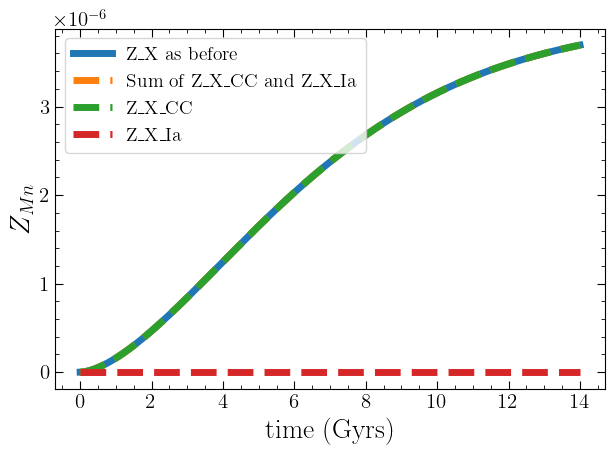

In [20]:
plt.Figure(figsize=(12,10))
plt.plot(t_array, Z_X, linewidth = 5, label = 'Z_X as before')
plt.plot(t_array, Z_X_CC + Z_X_Ia, linestyle = '--', linewidth = 5, label = 'Sum of Z_X_CC and Z_X_Ia')
plt.plot(t_array, Z_X_CC, linestyle = '--', linewidth = 5, label = 'Z_X_CC')
plt.plot(t_array, Z_X_Ia, linestyle = '--', linewidth = 5, label = 'Z_X_Ia')

plt.xlabel("time (Gyrs)")
plt.ylabel(r"$Z_{Mn}$")

plt.legend()

plt.tight_layout()

In [21]:
import numpy as np

# Using np.allclose is best to avoid floating-point rounding errors
all_match = np.allclose(Z_X_CC + Z_X_Ia, Z_X)

print(f"Does sum of Z_X_CC and Z_X_Ia equal Z_X? {all_match}")

# If you need a boolean mask for row-by-row checks:
match_mask = np.isclose(Z_X_CC + Z_X_Ia, Z_X)

Does sum of Z_X_CC and Z_X_Ia equal Z_X? True


In [22]:
SolarO = 73.3e-4
SolarFe = 13.7e-4
SolarMg = 6.71e-4
SolarMn = 1.29e-05 #Magg et al. 2022
SolarAl = 2.69e-6      #Magg et al. 2022

def ratio_to_sun(star, sun):
        ratio = np.log10(star/sun + 1e-6)
        return ratio


Mn_H_CC = ratio_to_sun(star=Z_X_CC, sun=SolarMn)
Mn_H_Ia = ratio_to_sun(star=Z_X_Ia, sun=SolarMn)

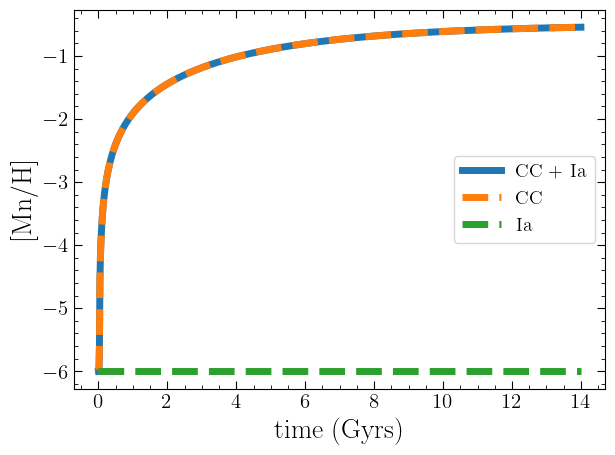

In [23]:
plt.Figure(figsize=(12,10))
plt.plot(t_array, example_gal.Mn_H, linewidth = 5, label = 'CC + Ia')
plt.plot(t_array, Mn_H_CC, linestyle = '--', linewidth = 5, label = 'CC')
plt.plot(t_array, Mn_H_Ia, linestyle = '--', linewidth = 5, label = 'Ia')

plt.xlabel("time (Gyrs)")
plt.ylabel("[Mn/H]")

plt.legend()

plt.tight_layout()

In [24]:
ratio = example_gal.compute_z_X_Ia()/example_gal.compute_z_X_CC()

/var/folders/g0/fl404sj151l2v9xcdkjz9fq80000gn/T/ipykernel_23247/4225234768.py:1: RuntimeWarning: invalid value encountered in divide
  ratio = example_gal.compute_z_X_Ia()/example_gal.compute_z_X_CC()


In [25]:
def find_endpoints(galaxies, bin_centers):
    endpoints_gals = []

    for bin_cent in bin_centers:
        endpoints = []
        for gal in galaxies:
            mg_h = gal.Mg_H
            for indx in range(len(mg_h)):
                mg_h_at_time = mg_h[indx]
                if mg_h_at_time > bin_cent:
                    endpoints.append(indx)
                    break

        endpoints_gals.append(np.array(endpoints))

    return endpoints_gals

fe_mg_bin_edges = np.arange(-0.35, 0.15, 0.1)
fe_mg_bin_centers = 0.5 * (fe_mg_bin_edges[:-1] + fe_mg_bin_edges[1:])

In [29]:
import matplotlib.colors as mcolors
import matplotlib.cm as cm

tol = np.diff(mg_h_big_bin_centers).mean() / 10 # adaptive tolerance
# Pre-calculate ratios and find the max value ONLY among the plotted scatter points
all_ratios = []
scatter_maxes = []

for gal in random_gals_list:
    ratio = gal.compute_z_X_Ia() / gal.compute_z_X_CC()
    all_ratios.append(ratio)
    
    diff = np.abs(gal.Mg_H[:, None] - mg_h_big_bin_centers[None, :])
    idx = diff.argmin(axis=0)
    min_diff = diff[idx, np.arange(diff.shape[1])]
    valid = min_diff < tol
    idx_valid = idx[valid]
    
    if len(idx_valid) > 0:
        scatter_maxes.append(np.nanmax(ratio[idx_valid]))

vmin = 0
vmax = max(scatter_maxes) if scatter_maxes else 1 # fallback just in case
norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
cmap = plt.get_cmap('inferno')

/var/folders/g0/fl404sj151l2v9xcdkjz9fq80000gn/T/ipykernel_23247/995133163.py:10: RuntimeWarning: invalid value encountered in divide
  ratio = gal.compute_z_X_Ia() / gal.compute_z_X_CC()


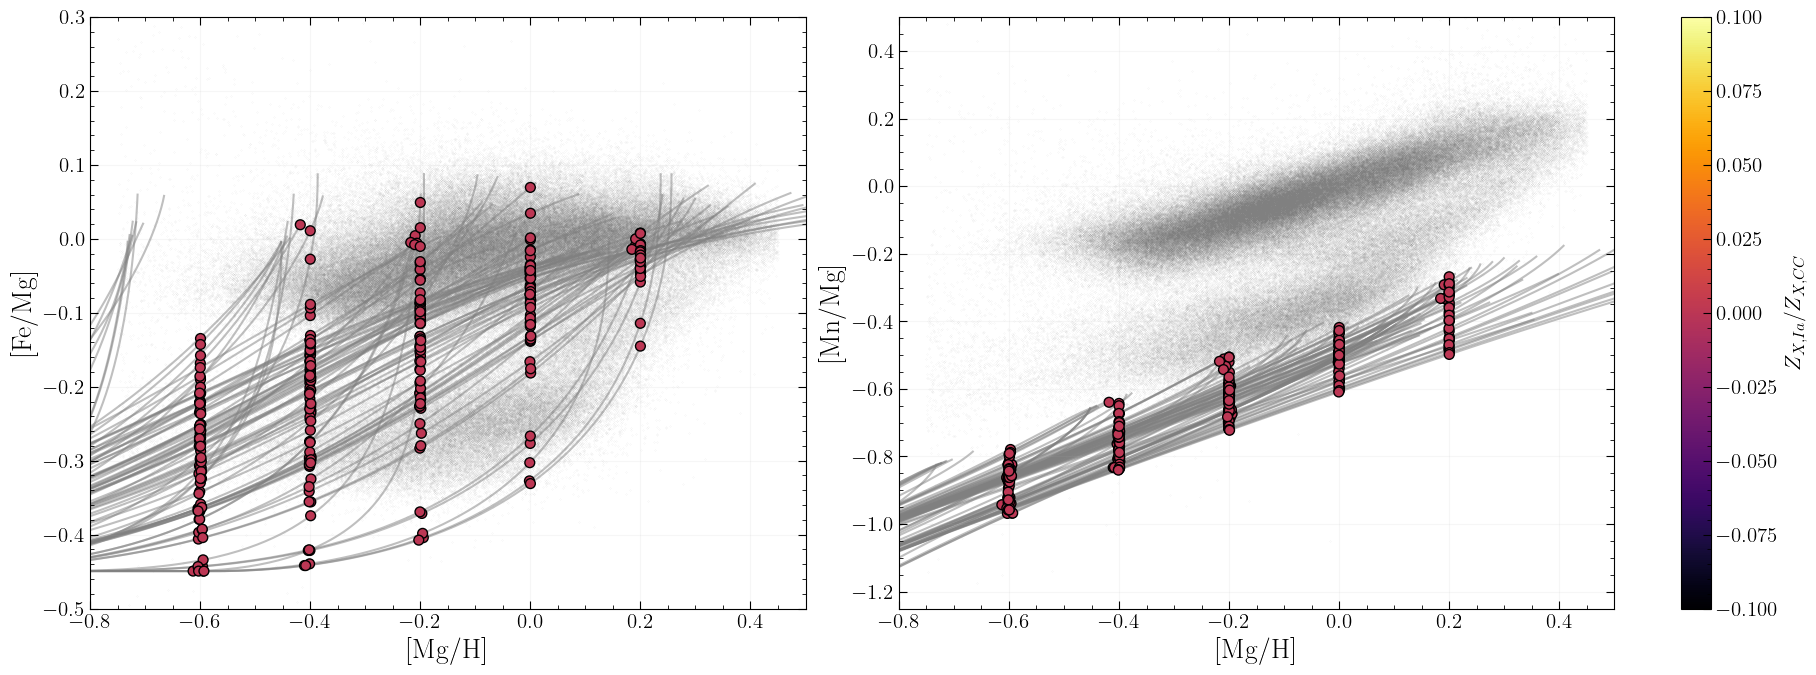

In [30]:
plt.figure(figsize=(18,7))

plt.subplot(1,2,1)
plt.scatter(data['MG_H'], data['FE_MG'], s = 0.01, color = 'gray', alpha = 0.3)

for i, gal in enumerate(random_gals_list):
    eta = gal.eta_arr[0]
    taustar = gal.tau_star_arr[0]
    sfr = gal.m_g_array
    
    if np.array_equal(sfr, m_g_array_const):
        sfr_label = "const SFR"
    elif np.array_equal(sfr, m_g_array_exp):
        sfr_label = "exp SFR"
    elif np.array_equal(sfr, m_g_array_rise_fall_1):
        sfr_label = "rise+fall  1"
    elif np.array_equal(sfr, m_g_array_rise_fall_2):
        sfr_label = "rise+fall  2"
    elif np.array_equal(sfr, m_g_array_rise_fall_3):
        sfr_label = "rise+fall  3"
    else:
        sfr_label = "unknown SFR"
        
    ratio = all_ratios[i]
        
    plt.plot(gal.Mg_H, gal.Fe_Mg, color='gray', alpha=0.5, zorder=1)
    
    diff = np.abs(gal.Mg_H[:, None] - mg_h_big_bin_centers[None, :])
    idx = diff.argmin(axis=0)
    min_diff = diff[idx, np.arange(diff.shape[1])]
    valid = min_diff < tol
    idx_valid = idx[valid]
    
    plt.scatter(gal.Mg_H[idx_valid], gal.Fe_Mg[idx_valid], s=50, zorder=10, marker='o', edgecolors='black',
                c=ratio[idx_valid], cmap=cmap, norm=norm,
                label = rf"$\eta = {eta:.2f}, \ \tau_* = {taustar}$, {sfr_label}")

plt.xlim(-0.8, 0.5)
plt.ylim(-0.5, 0.3)
plt.xlabel('[Mg/H]')
plt.ylabel('[Fe/Mg]')
plt.grid(True, alpha = 0.1)       

plt.subplot(1,2,2)
plt.scatter(data['MG_H'], data['MN_MG'], s = 0.01, color = 'gray', alpha = 0.3)

for i, gal in enumerate(random_gals_list):
    ratio = all_ratios[i]
    
    plt.plot(gal.Mg_H, gal.Mn_Mg, color='gray', alpha=0.5, zorder=1)
    
    diff = np.abs(gal.Mg_H[:, None] - mg_h_big_bin_centers[None, :])
    idx = diff.argmin(axis=0)
    min_diff = diff[idx, np.arange(diff.shape[1])]
    valid = min_diff < tol
    idx_valid = idx[valid]
    
    sc = plt.scatter(gal.Mg_H[idx_valid], gal.Mn_Mg[idx_valid], s=50, zorder=10, marker='o', edgecolors='black',
                     c=ratio[idx_valid], cmap=cmap, norm=norm)

plt.xlim(-0.8, 0.5)
plt.ylim(-1.25, 0.5)
plt.xlabel('[Mg/H]')
plt.ylabel('[Mn/Mg]')
plt.grid(True, alpha = 0.1)

plt.tight_layout()

cbar = plt.colorbar(sc, ax=plt.gcf().axes, fraction=0.05, pad=0.04)
cbar.set_label(r'$Z_{X, Ia} / Z_{X, CC}$', fontsize=16)
plt.show()

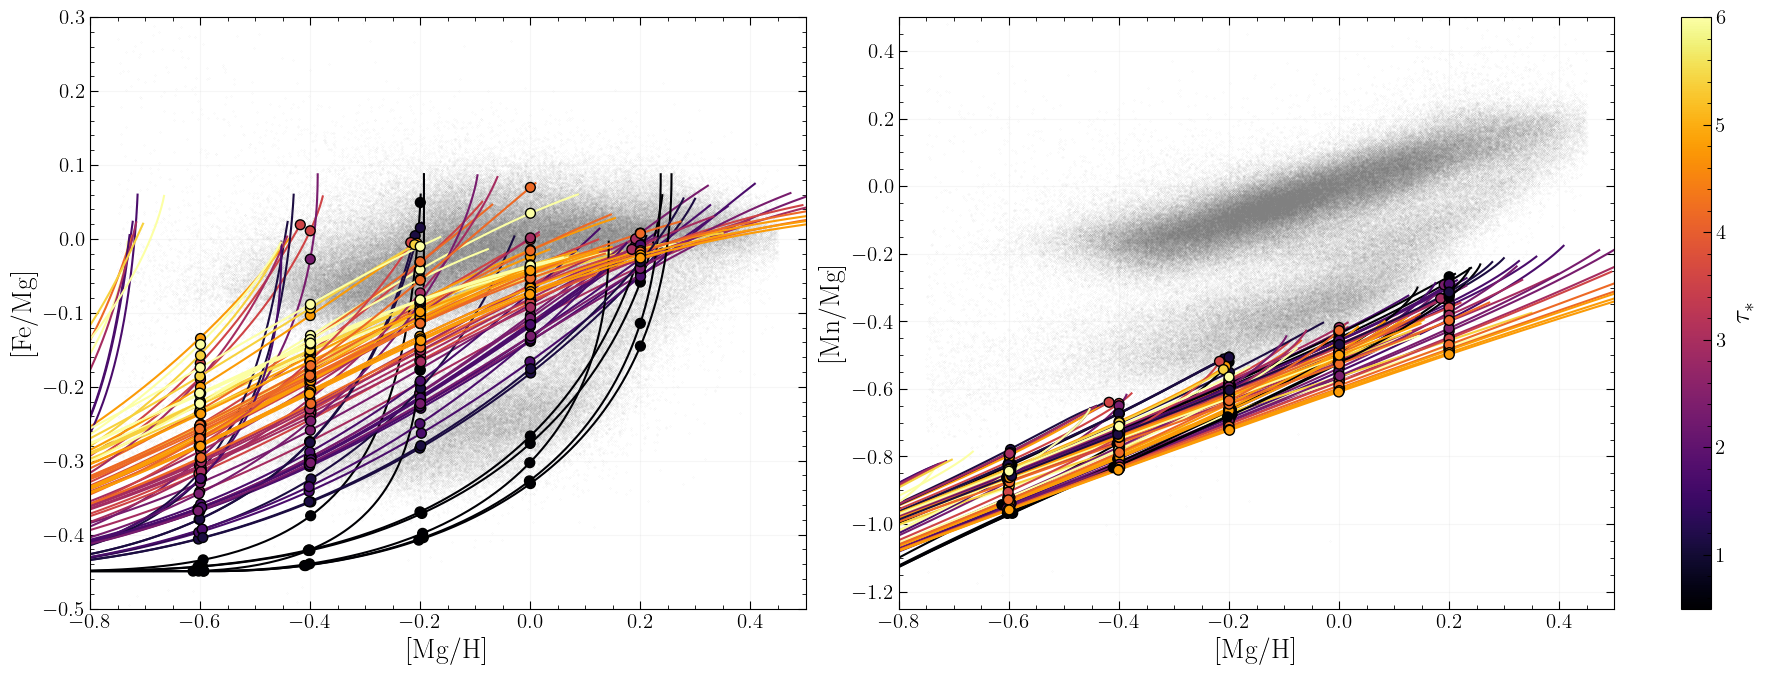

In [33]:
# --- NEW: Extract tau* values to normalize the colormap ---
tau_stars = [gal.tau_star_arr[0] for gal in random_gals_list]
vmin, vmax = min(tau_stars), max(tau_stars)
norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
cmap = plt.get_cmap('inferno')

plt.figure(figsize=(18,7))
tol = np.diff(mg_h_big_bin_centers).mean() / 10 # adaptive tolerance

plt.subplot(1,2,1)
plt.scatter(data['MG_H'], data['FE_MG'], s = 0.01, color = 'gray', alpha = 0.3)

for i in range(len(random_gals_list)):
    gal = random_gals_list[i]
    eta = gal.eta_arr[0]
    taustar = gal.tau_star_arr[0]
    sfr = gal.m_g_array
    if np.array_equal(sfr, m_g_array_const):
        sfr_label = "const SFR"
    elif np.array_equal(sfr, m_g_array_exp):
        sfr_label = "exp SFR"
    elif np.array_equal(sfr, m_g_array_rise_fall_1):
        sfr_label = "rise+fall  1"
    elif np.array_equal(sfr, m_g_array_rise_fall_2):
        sfr_label = "rise+fall  2"
    elif np.array_equal(sfr, m_g_array_rise_fall_3):
        sfr_label = "rise+fall  3"
    else:
        sfr_label = "unknown SFR"
        
    # --- NEW: Get color for this specific tau* ---
    current_color = cmap(norm(taustar))
        
    plt.plot(gal.Mg_H, gal.Fe_Mg, color=current_color)
    
    diff = np.abs(gal.Mg_H[:, None] - mg_h_big_bin_centers[None, :])
    idx = diff.argmin(axis=0)
    min_diff = diff[idx, np.arange(diff.shape[1])]
    valid = min_diff < tol
    idx_valid = idx[valid]
    
    # --- NEW: Map c argument to tau* ---
    plt.scatter(gal.Mg_H[idx_valid], gal.Fe_Mg[idx_valid], s=50, zorder=10, marker='o', edgecolors='black',
                c=[taustar]*len(idx_valid), cmap=cmap, norm=norm,
                label = rf"$\eta = {eta:.2f}, \ \tau_* = {taustar}$, {sfr_label}")

#plt.legend(loc='center right', bbox_to_anchor=(-0.25, 0.5), fontsize=14)
plt.xlim(-0.8, 0.5)
plt.ylim(-0.5, 0.3)
plt.xlabel('[Mg/H]')
plt.ylabel('[Fe/Mg]')
plt.grid(True, alpha = 0.1)       


plt.subplot(1,2,2)
plt.scatter(data['MG_H'], data['MN_MG'], s = 0.01, color = 'gray', alpha = 0.3)

for i in range(len(random_gals_list)):
    gal = random_gals_list[i]
    taustar = gal.tau_star_arr[0]
    
    # --- NEW: Apply color mapping here too ---
    current_color = cmap(norm(taustar))
    
    plt.plot(gal.Mg_H, gal.Mn_Mg, color=current_color)
    
    diff = np.abs(gal.Mg_H[:, None] - mg_h_big_bin_centers[None, :])
    idx = diff.argmin(axis=0)
    min_diff = diff[idx, np.arange(diff.shape[1])]
    valid = min_diff < tol
    idx_valid = idx[valid]
    
    # --- NEW: Map c argument to tau* ---
    sc = plt.scatter(gal.Mg_H[idx_valid], gal.Mn_Mg[idx_valid], s=50, zorder=10, marker='o', edgecolors='black',
                     c=[taustar]*len(idx_valid), cmap=cmap, norm=norm)

#plt.legend()
plt.xlim(-0.8, 0.5)
plt.ylim(-1.25, 0.5)
plt.xlabel('[Mg/H]')
plt.ylabel('[Mn/Mg]')
plt.grid(True, alpha = 0.1)

plt.tight_layout()

# --- NEW: Add a shared colorbar for both subplots ---
cbar = plt.colorbar(sc, ax=plt.gcf().axes, fraction=0.05, pad=0.04)
cbar.set_label(r'$\tau_*$', fontsize=20)
plt.show()

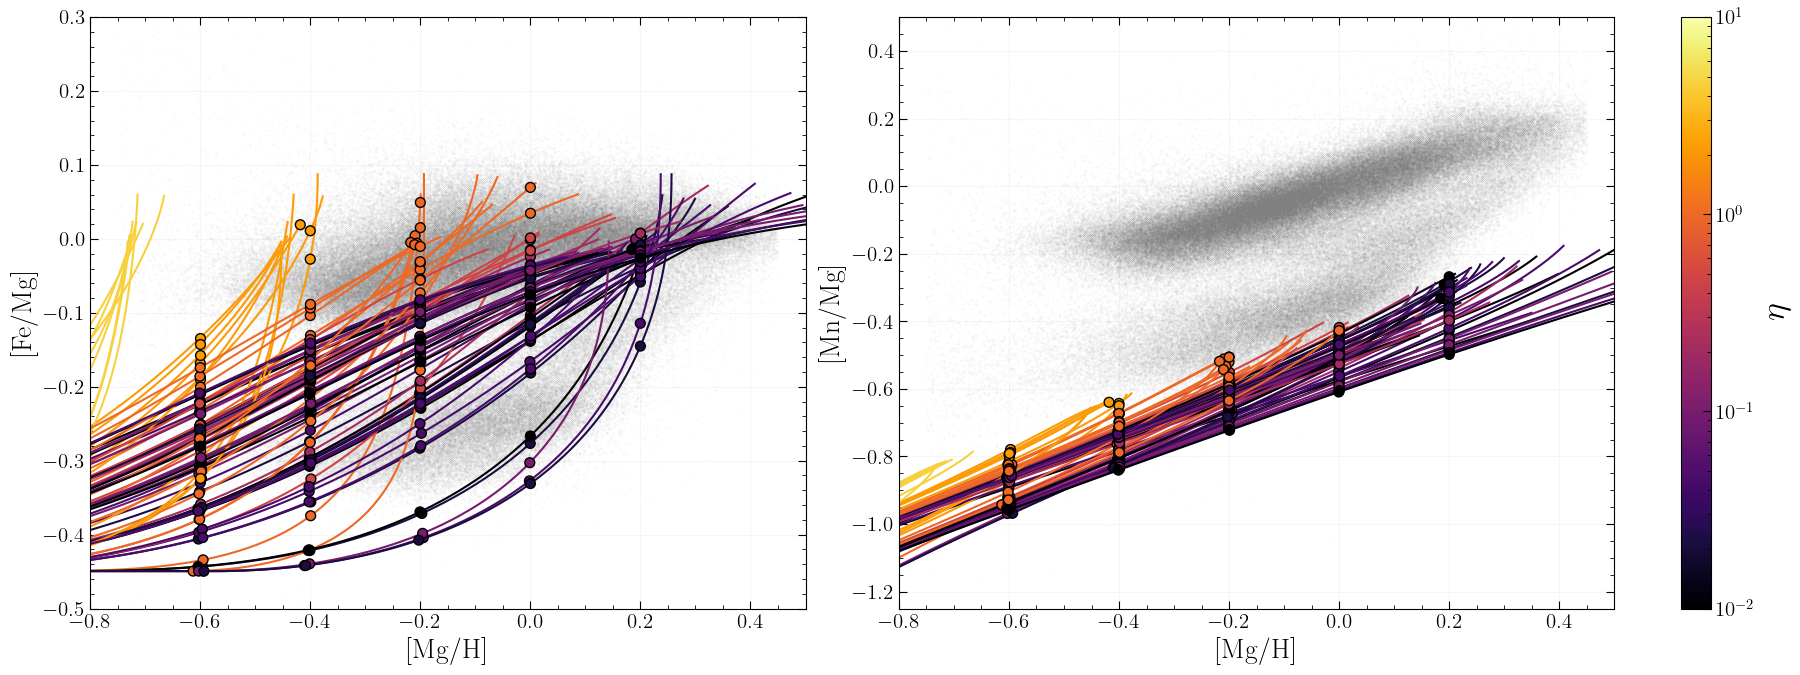

In [34]:
# --- NEW: Extract tau* values to normalize the colormap ---
etas_for_plotting = [gal.eta_arr[0] for gal in random_gals_list]
vmin, vmax = min(etas_for_plotting), max(etas_for_plotting)
norm = mcolors.LogNorm(vmin=vmin, vmax=vmax)
cmap = plt.get_cmap('inferno')

plt.figure(figsize=(18,7))
tol = np.diff(mg_h_big_bin_centers).mean() / 10 # adaptive tolerance

plt.subplot(1,2,1)
plt.scatter(data['MG_H'], data['FE_MG'], s = 0.01, color = 'gray', alpha = 0.3)

for i in range(len(random_gals_list)):
    gal = random_gals_list[i]
    eta = gal.eta_arr[0]
    taustar = gal.tau_star_arr[0]
    sfr = gal.m_g_array
    if np.array_equal(sfr, m_g_array_const):
        sfr_label = "const SFR"
    elif np.array_equal(sfr, m_g_array_exp):
        sfr_label = "exp SFR"
    elif np.array_equal(sfr, m_g_array_rise_fall_1):
        sfr_label = "rise+fall  1"
    elif np.array_equal(sfr, m_g_array_rise_fall_2):
        sfr_label = "rise+fall  2"
    elif np.array_equal(sfr, m_g_array_rise_fall_3):
        sfr_label = "rise+fall  3"
    else:
        sfr_label = "unknown SFR"
        
    # --- NEW: Get color for this specific tau* ---
    current_color = cmap(norm(eta))
        
    plt.plot(gal.Mg_H, gal.Fe_Mg, color=current_color)
    
    diff = np.abs(gal.Mg_H[:, None] - mg_h_big_bin_centers[None, :])
    idx = diff.argmin(axis=0)
    min_diff = diff[idx, np.arange(diff.shape[1])]
    valid = min_diff < tol
    idx_valid = idx[valid]
    
    # --- NEW: Map c argument to eta ---
    plt.scatter(gal.Mg_H[idx_valid], gal.Fe_Mg[idx_valid], s=50, zorder=10, marker='o', edgecolors='black',
                c=[eta]*len(idx_valid), cmap=cmap, norm=norm,
                label = rf"$\eta = {eta:.2f}, \ \tau_* = {taustar}$, {sfr_label}")

#plt.legend(loc='center right', bbox_to_anchor=(-0.25, 0.5), fontsize=14)
plt.xlim(-0.8, 0.5)
plt.ylim(-0.5, 0.3)
plt.xlabel('[Mg/H]')
plt.ylabel('[Fe/Mg]')
plt.grid(True, alpha = 0.1)       


plt.subplot(1,2,2)
plt.scatter(data['MG_H'], data['MN_MG'], s = 0.01, color = 'gray', alpha = 0.3)

for i in range(len(random_gals_list)):
    gal = random_gals_list[i]
    taustar = gal.tau_star_arr[0]
    eta = gal.eta_arr[0]
    
    # --- NEW: Apply color mapping here too ---
    current_color = cmap(norm(eta))
    
    plt.plot(gal.Mg_H, gal.Mn_Mg, color=current_color)
    
    diff = np.abs(gal.Mg_H[:, None] - mg_h_big_bin_centers[None, :])
    idx = diff.argmin(axis=0)
    min_diff = diff[idx, np.arange(diff.shape[1])]
    valid = min_diff < tol
    idx_valid = idx[valid]
    
    # --- NEW: Map c argument to eta ---
    sc = plt.scatter(gal.Mg_H[idx_valid], gal.Mn_Mg[idx_valid], s=50, zorder=10, marker='o', edgecolors='black',
                     c=[eta]*len(idx_valid), cmap=cmap, norm=norm)

#plt.legend()
plt.xlim(-0.8, 0.5)
plt.ylim(-1.25, 0.5)
plt.xlabel('[Mg/H]')
plt.ylabel('[Mn/Mg]')
plt.grid(True, alpha = 0.1)

plt.tight_layout()

# --- NEW: Add a shared colorbar for both subplots ---
cbar = plt.colorbar(sc, ax=plt.gcf().axes, fraction=0.05, pad=0.04)
cbar.set_label(r'$\eta$', fontsize=25)
plt.show()

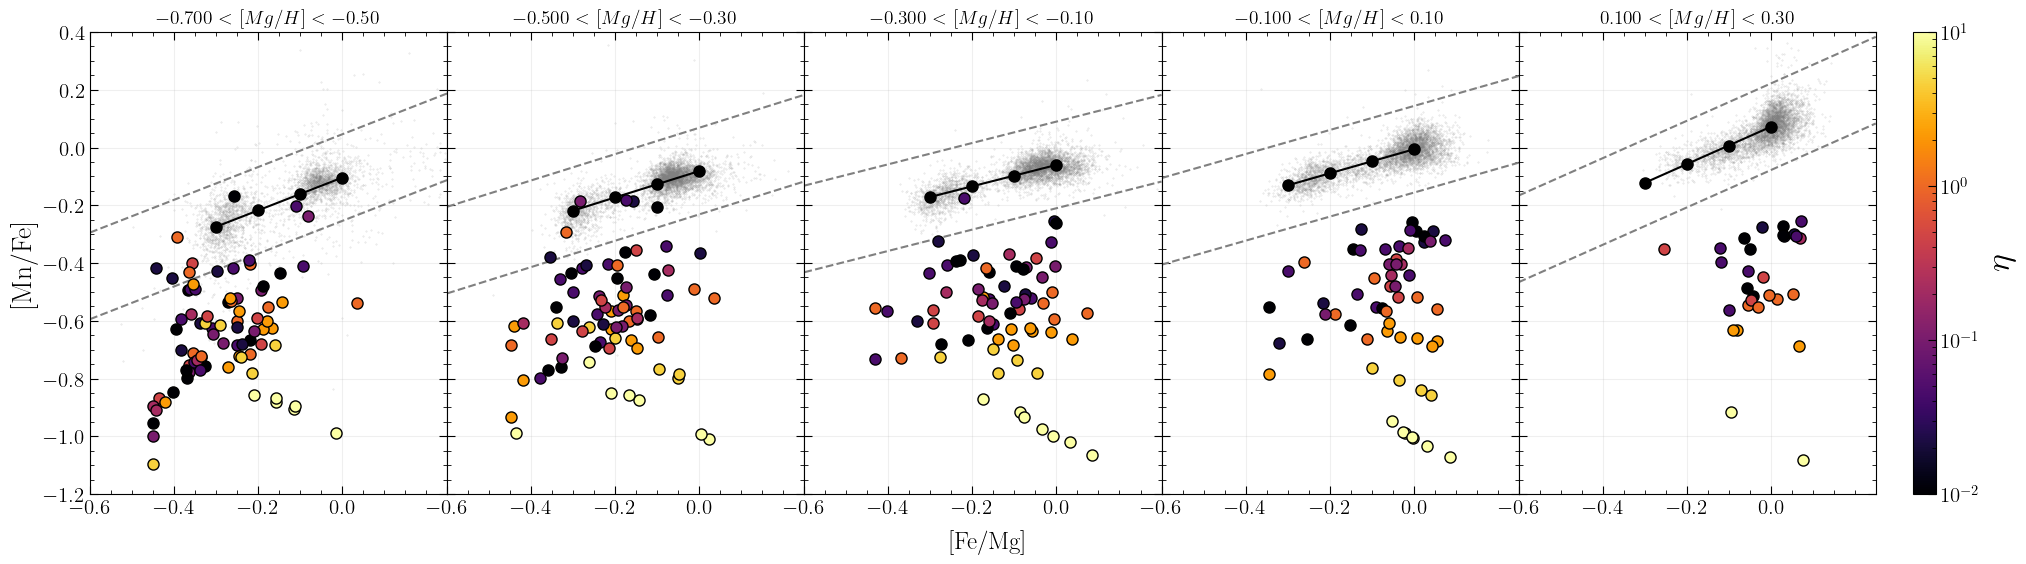

In [35]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm

# --- Set figure dimensions directly ---
fig_x = 24
fig_y = 6
gals_list = random_gals_list

# --- Extract eta values for the colormap ---
etas = [gal.eta_arr[0] for gal in gals_list]
norm = mcolors.LogNorm(vmin=min(etas), vmax=max(etas))
cmap = plt.get_cmap('inferno')

fig, axes = plt.subplots(1, 5, figsize=(fig_x, fig_y), sharex=True, sharey=True)
axes = axes.flatten()

# Pre-calculate endpoints for all galaxies across all bin centers
gals_endpoints = find_endpoints(gals_list, mg_h_big_bin_centers)

for i, ax in enumerate(axes):
    # Plot background data
    downsampled_data = downsample(data[data['MG_H_big_bin'] == i], 5000)
    ax.scatter(downsampled_data['FE_MG'], downsampled_data['MN_FE'], s=0.1, color='gray', alpha=0.3)

    # Plot median line
    y_centers = slopes_mn_fe[i] * fe_mg_bin_centers + intercepts_mn_fe[i]
    y_lower = slopes_mn_fe[i] * np.linspace(-0.6, 0.25, 100) + intercepts_mn_fe[i] - 0.15
    y_upper = slopes_mn_fe[i] * np.linspace(-0.6, 0.25, 100) + intercepts_mn_fe[i] + 0.15
    ax.plot(fe_mg_bin_centers, y_centers, '-o', color='black', ms=8, zorder=10)

    # --- NEW: Plot parallel lines +/- 0.1 dex ---
    ax.plot(np.linspace(-0.6, 0.25, 100), y_lower, color = 'gray', linestyle = '--')
    ax.plot(np.linspace(-0.6, 0.25, 100), y_upper, color = 'gray', linestyle = '--')

    # idxs contains the stopping index for EACH galaxy in gals_list for this bin 'i'
    idxs = gals_endpoints[i]

    for k, (gal, idx) in enumerate(zip(gals_list, idxs)):
        if idx != -1:  # Ensure the galaxy actually crossed this bin center
            fe_mg = gal.Fe_Mg[idx]
            mn_fe = gal.Mn_Fe[idx]
            
            eta = gal.eta_arr[0]
            taustar = gal.tau_star_arr[0]
            
            # Get dynamic color
            current_color = cmap(norm(eta))
            
            sfr = gal.m_g_array
            if np.array_equal(sfr, m_g_array_const):
                sfr_label = "const SFR"
            elif np.array_equal(sfr, m_g_array_exp):
                sfr_label = "exp SFR"
            elif np.array_equal(sfr, m_g_array_rise_fall_1):
                sfr_label = "rise+fall  1"
            elif np.array_equal(sfr, m_g_array_rise_fall_2):
                sfr_label = "rise+fall  2"
            elif np.array_equal(sfr, m_g_array_rise_fall_3):
                sfr_label = "rise+fall  3"
            else:
                sfr_label = "unknown SFR"

            ax.plot(fe_mg, mn_fe, marker='o', color=current_color, linewidth=0,
                    markeredgecolor='black', markersize=8, zorder=11,
                    label = rf"$\eta = {eta:.2f}, \ \tau_* = {taustar}$, {sfr_label}")

    if i == 0:
        ax.set_ylabel('[Mn/Fe]')
    
    ax.set_title(
        rf'${mg_h_big_bin_edges[i]:.3f} < [Mg/H] < {mg_h_big_bin_edges[i+1]:.2f}$',
        fontsize=14
    )
    ax.set_xticks(np.arange(-0.6, 0.2, 0.2))
    ax.grid(True, alpha=0.2)
    ax.set_xlim(-0.60, 0.25)
    ax.set_ylim(-1.2, 0.40)

fig.supxlabel('[Fe/Mg]')
fig.subplots_adjust(wspace=0)

# Add the colorbar using ScalarMappable
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([]) 
cbar = fig.colorbar(sm, ax=axes, fraction=0.02, pad=0.02)
cbar.set_label(r'$\eta$', fontsize=25)

plt.show()

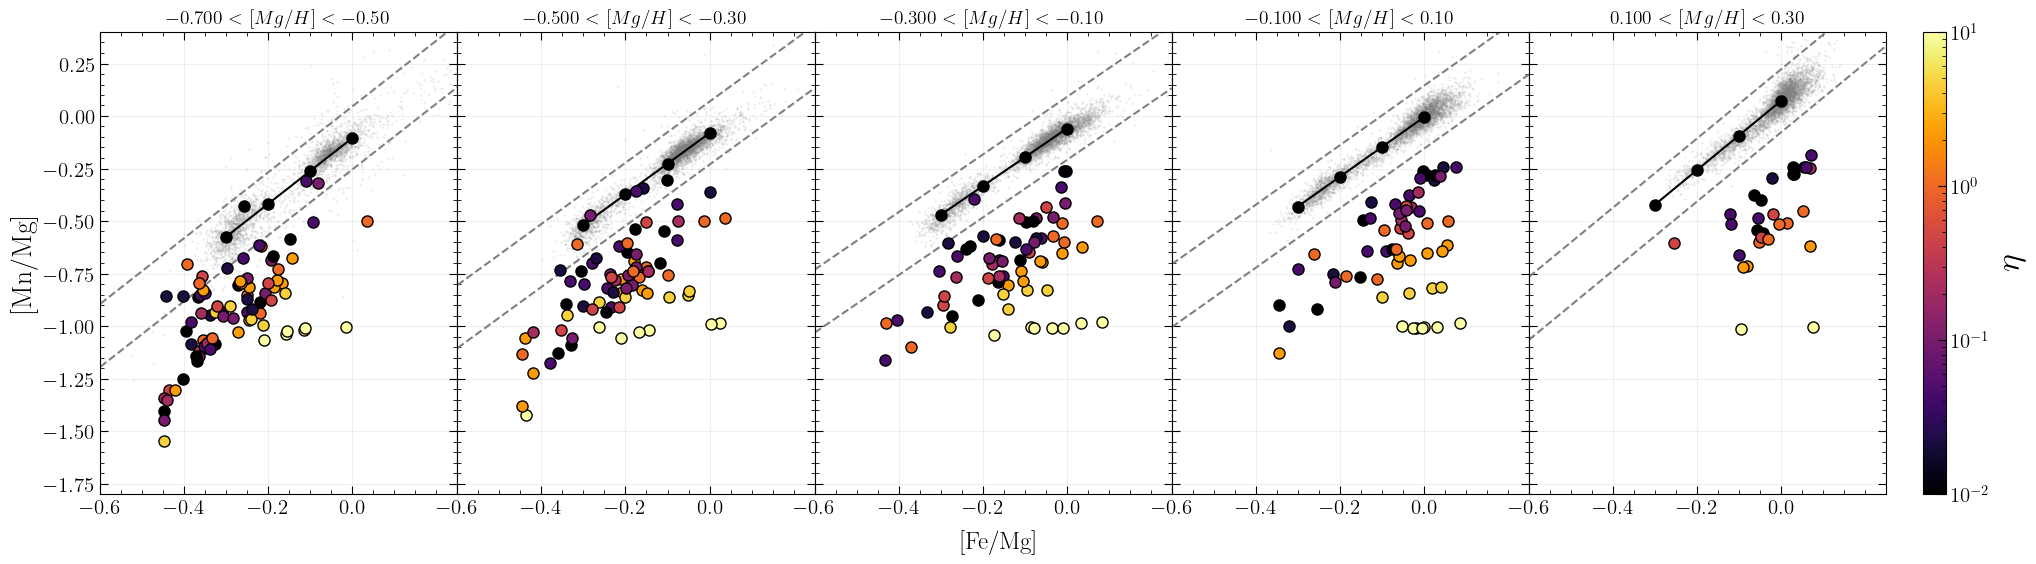

In [37]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm

fig_x = 24
fig_y = 6
gals_list = random_gals_list

etas = [gal.eta_arr[0] for gal in gals_list]
norm = mcolors.LogNorm(vmin=min(etas), vmax=max(etas))
cmap = plt.get_cmap('inferno')

fig, axes = plt.subplots(1, 5, figsize=(fig_x, fig_y), sharex=True, sharey=True)
axes = axes.flatten()

gals_endpoints = find_endpoints(gals_list, mg_h_big_bin_centers)

for i, ax in enumerate(axes):
    downsampled_data = downsample(data[data['MG_H_big_bin'] == i], 5000)
    ax.scatter(downsampled_data['FE_MG'], downsampled_data['MN_MG'], s=0.1, color='gray', alpha=0.3)

    y_centers = slopes_mn_mg[i] * fe_mg_bin_centers + intercepts_mn_mg[i]
    y_lower = slopes_mn_mg[i] * np.linspace(-0.6, 0.25, 100) + intercepts_mn_mg[i] - 0.15
    y_upper = slopes_mn_mg[i] * np.linspace(-0.6, 0.25, 100) + intercepts_mn_mg[i] + 0.15
    ax.plot(fe_mg_bin_centers, y_centers, '-o', color='black', ms=8, zorder=10)

    ax.plot(np.linspace(-0.6, 0.25, 100), y_lower, color='gray', linestyle='--')
    ax.plot(np.linspace(-0.6, 0.25, 100), y_upper, color='gray', linestyle='--')

    idxs = gals_endpoints[i]

    for k, (gal, idx) in enumerate(zip(gals_list, idxs)):
        if idx != -1: 
            fe_mg = gal.Fe_Mg[idx]
            mn_mg = gal.Mn_Mg[idx]
            
            eta = gal.eta_arr[0]
            taustar = gal.tau_star_arr[0]
            current_color = cmap(norm(eta))
            
            sfr = gal.m_g_array
            if np.array_equal(sfr, m_g_array_const):
                sfr_label = "const SFR"
            elif np.array_equal(sfr, m_g_array_exp):
                sfr_label = "exp SFR"
            elif np.array_equal(sfr, m_g_array_rise_fall_1):
                sfr_label = "rise+fall  1"
            elif np.array_equal(sfr, m_g_array_rise_fall_2):
                sfr_label = "rise+fall  2"
            elif np.array_equal(sfr, m_g_array_rise_fall_3):
                sfr_label = "rise+fall  3"
            else:
                sfr_label = "unknown SFR"

            ax.plot(fe_mg, mn_mg, marker='o', color=current_color, linewidth=0,
                    markeredgecolor='black', markersize=8, zorder=11,
                    label = rf"$\eta = {eta:.2f}, \ \tau_* = {taustar}$, {sfr_label}")

    if i == 0:
        ax.set_ylabel('[Mn/Mg]')
    
    ax.set_title(
        rf'${mg_h_big_bin_edges[i]:.3f} < [Mg/H] < {mg_h_big_bin_edges[i+1]:.2f}$',
        fontsize=14
    )
    ax.set_xticks(np.arange(-0.6, 0.2, 0.2))
    ax.grid(True, alpha=0.2)
    ax.set_xlim(-0.60, 0.25)
    ax.set_ylim(-1.8, 0.40) 

fig.supxlabel('[Fe/Mg]')
fig.subplots_adjust(wspace=0)

sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([]) 
cbar = fig.colorbar(sm, ax=axes, fraction=0.02, pad=0.02)
cbar.set_label(r'$\eta$', fontsize=25)

plt.show()

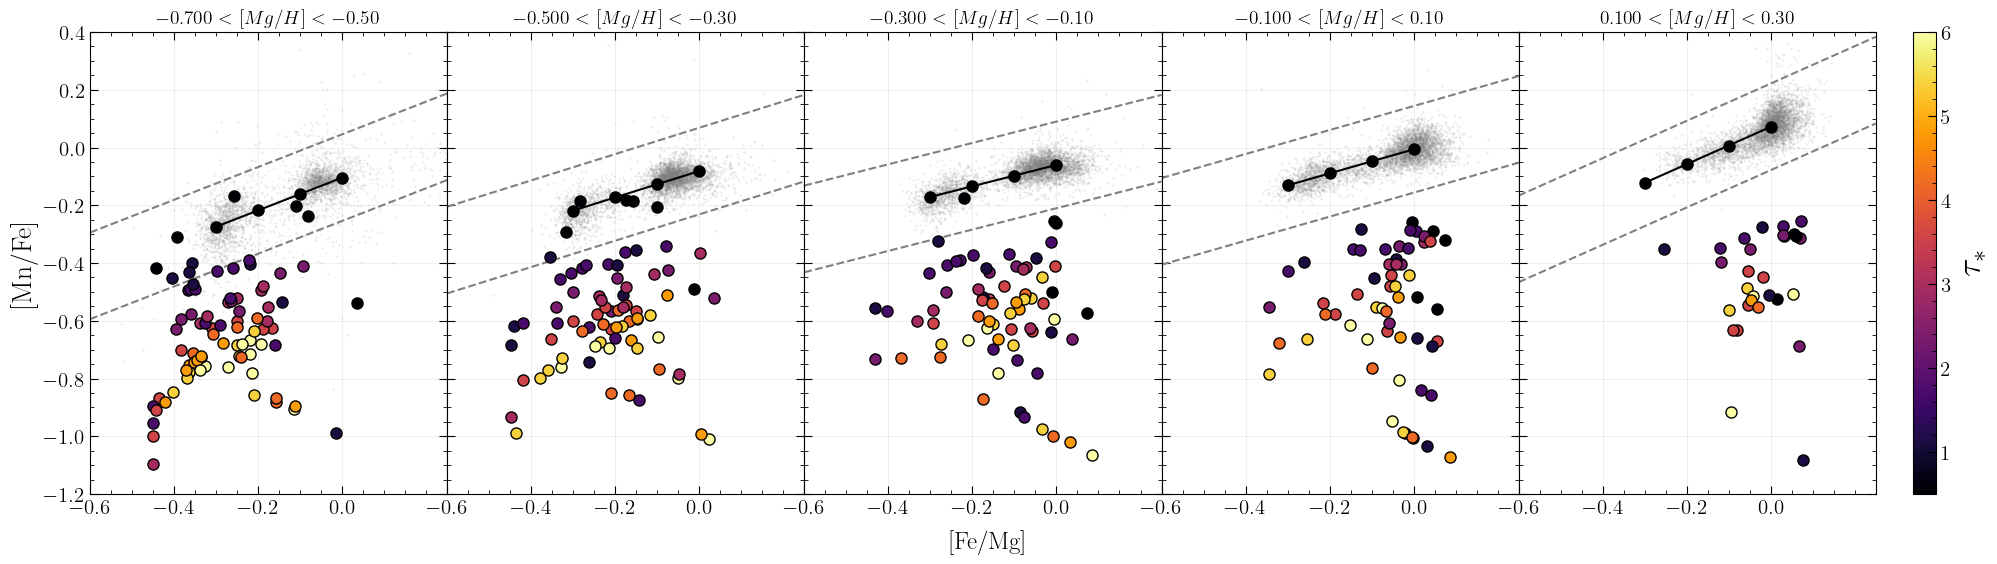

In [36]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm

# --- Set figure dimensions directly ---
fig_x = 24
fig_y = 6
gals_list = random_gals_list
# --- Extract tau* values for the colormap ---
tau_stars = [gal.tau_star_arr[0] for gal in gals_list]
norm = mcolors.Normalize(vmin=min(tau_stars), vmax=max(tau_stars))
cmap = plt.get_cmap('inferno')

fig, axes = plt.subplots(1, 5, figsize=(fig_x, fig_y), sharex=True, sharey=True)
axes = axes.flatten()

# Pre-calculate endpoints for all galaxies across all bin centers
gals_endpoints = find_endpoints(gals_list, mg_h_big_bin_centers)

for i, ax in enumerate(axes):
    # Plot background data
    downsampled_data = downsample(data[data['MG_H_big_bin'] == i], 5000)
    ax.scatter(downsampled_data['FE_MG'], downsampled_data['MN_FE'], s=0.1, color='gray', alpha=0.3)

    # Plot median line
    y_centers = slopes_mn_fe[i] * fe_mg_bin_centers + intercepts_mn_fe[i]
    y_lower = slopes_mn_fe[i] * np.linspace(-0.6, 0.25, 100) + intercepts_mn_fe[i] - 0.15
    y_upper = slopes_mn_fe[i] * np.linspace(-0.6, 0.25, 100) + intercepts_mn_fe[i] + 0.15
    ax.plot(fe_mg_bin_centers, y_centers, '-o', color='black', ms=8, zorder=10)

    # --- NEW: Plot parallel lines +/- 0.1 dex ---
    ax.plot(np.linspace(-0.6, 0.25, 100), y_lower, color = 'gray', linestyle = '--')
    ax.plot(np.linspace(-0.6, 0.25, 100), y_upper, color = 'gray', linestyle = '--')


    # idxs contains the stopping index for EACH galaxy in gals_list for this bin 'i'
    idxs = gals_endpoints[i]

    for k, (gal, idx) in enumerate(zip(gals_list, idxs)):
        if idx != -1:  # Ensure the galaxy actually crossed this bin center
            fe_mg = gal.Fe_Mg[idx]
            mn_fe = gal.Mn_Fe[idx]
            
            eta = gal.eta_arr[0]
            taustar = gal.tau_star_arr[0]
            
            # Get dynamic color
            current_color = cmap(norm(taustar))
            
            sfr = gal.m_g_array
            if np.array_equal(sfr, m_g_array_const):
                sfr_label = "const SFR"
            elif np.array_equal(sfr, m_g_array_exp):
                sfr_label = "exp SFR"
            elif np.array_equal(sfr, m_g_array_rise_fall_1):
                sfr_label = "rise+fall  1"
            elif np.array_equal(sfr, m_g_array_rise_fall_2):
                sfr_label = "rise+fall  2"
            elif np.array_equal(sfr, m_g_array_rise_fall_3):
                sfr_label = "rise+fall  3"
            else:
                sfr_label = "unknown SFR"

            ax.plot(fe_mg, mn_fe, marker='o', color=current_color, linewidth=0,
                    markeredgecolor='black', markersize=8, zorder=11,
                    label = rf"$\eta = {eta:.2f}, \ \tau_* = {taustar}$, {sfr_label}")

    if i == 0:
        ax.set_ylabel('[Mn/Fe]')
    
    ax.set_title(
        rf'${mg_h_big_bin_edges[i]:.3f} < [Mg/H] < {mg_h_big_bin_edges[i+1]:.2f}$',
        fontsize=14
    )
    ax.set_xticks(np.arange(-0.6, 0.2, 0.2))
    ax.grid(True, alpha=0.2)
    ax.set_xlim(-0.60, 0.25)
    ax.set_ylim(-1.2, 0.40)

fig.supxlabel('[Fe/Mg]')
fig.subplots_adjust(wspace=0)

# Add the colorbar using ScalarMappable
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([]) 
cbar = fig.colorbar(sm, ax=axes, fraction=0.02, pad=0.02)
cbar.set_label(r'$\tau_*$', fontsize=25)

plt.show()

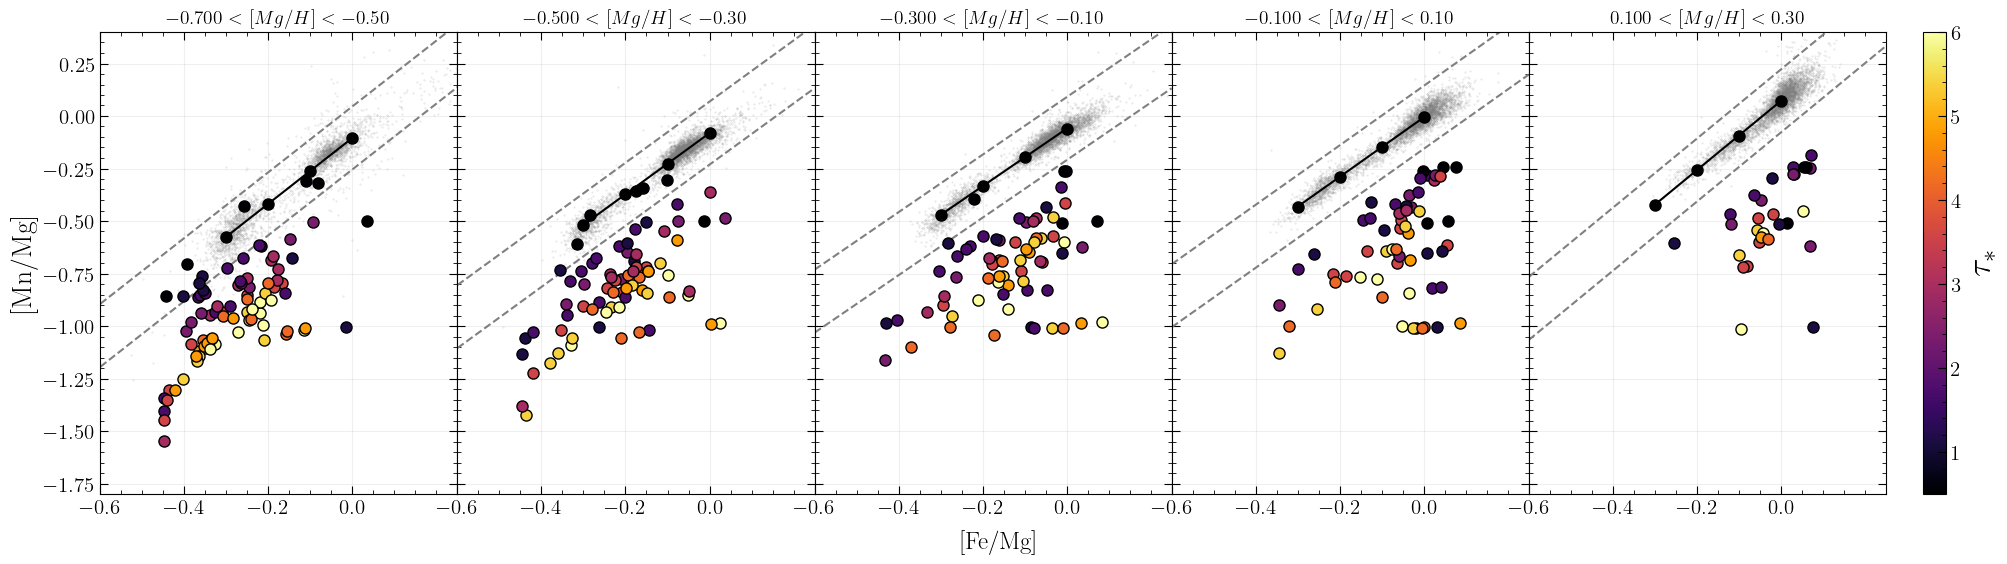

In [38]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm

fig_x = 24
fig_y = 6
gals_list = random_gals_list

tau_stars = [gal.tau_star_arr[0] for gal in gals_list]
norm = mcolors.Normalize(vmin=min(tau_stars), vmax=max(tau_stars))
cmap = plt.get_cmap('inferno')

fig, axes = plt.subplots(1, 5, figsize=(fig_x, fig_y), sharex=True, sharey=True)
axes = axes.flatten()

gals_endpoints = find_endpoints(gals_list, mg_h_big_bin_centers)

for i, ax in enumerate(axes):
    downsampled_data = downsample(data[data['MG_H_big_bin'] == i], 5000)
    ax.scatter(downsampled_data['FE_MG'], downsampled_data['MN_MG'], s=0.1, color='gray', alpha=0.3)

    y_centers = slopes_mn_mg[i] * fe_mg_bin_centers + intercepts_mn_mg[i]
    y_lower = slopes_mn_mg[i] * np.linspace(-0.6, 0.25, 100) + intercepts_mn_mg[i] - 0.15
    y_upper = slopes_mn_mg[i] * np.linspace(-0.6, 0.25, 100) + intercepts_mn_mg[i] + 0.15
    ax.plot(fe_mg_bin_centers, y_centers, '-o', color='black', ms=8, zorder=10)

    ax.plot(np.linspace(-0.6, 0.25, 100), y_lower, color='gray', linestyle='--')
    ax.plot(np.linspace(-0.6, 0.25, 100), y_upper, color='gray', linestyle='--')

    idxs = gals_endpoints[i]

    for k, (gal, idx) in enumerate(zip(gals_list, idxs)):
        if idx != -1: 
            fe_mg = gal.Fe_Mg[idx]
            mn_mg = gal.Mn_Mg[idx]
            
            eta = gal.eta_arr[0]
            taustar = gal.tau_star_arr[0]
            current_color = cmap(norm(taustar))
            
            sfr = gal.m_g_array
            if np.array_equal(sfr, m_g_array_const):
                sfr_label = "const SFR"
            elif np.array_equal(sfr, m_g_array_exp):
                sfr_label = "exp SFR"
            elif np.array_equal(sfr, m_g_array_rise_fall_1):
                sfr_label = "rise+fall  1"
            elif np.array_equal(sfr, m_g_array_rise_fall_2):
                sfr_label = "rise+fall  2"
            elif np.array_equal(sfr, m_g_array_rise_fall_3):
                sfr_label = "rise+fall  3"
            else:
                sfr_label = "unknown SFR"

            ax.plot(fe_mg, mn_mg, marker='o', color=current_color, linewidth=0,
                    markeredgecolor='black', markersize=8, zorder=11,
                    label = rf"$\eta = {eta:.2f}, \ \tau_* = {taustar}$, {sfr_label}")

    if i == 0:
        ax.set_ylabel('[Mn/Mg]')
    
    ax.set_title(
        rf'${mg_h_big_bin_edges[i]:.3f} < [Mg/H] < {mg_h_big_bin_edges[i+1]:.2f}$',
        fontsize=14
    )
    ax.set_xticks(np.arange(-0.6, 0.2, 0.2))
    ax.grid(True, alpha=0.2)
    ax.set_xlim(-0.60, 0.25)
    ax.set_ylim(-1.8, 0.40) 

fig.supxlabel('[Fe/Mg]')
fig.subplots_adjust(wspace=0)

sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([]) 
cbar = fig.colorbar(sm, ax=axes, fraction=0.02, pad=0.02)
cbar.set_label(r'$\tau_*$', fontsize=25)

plt.show()

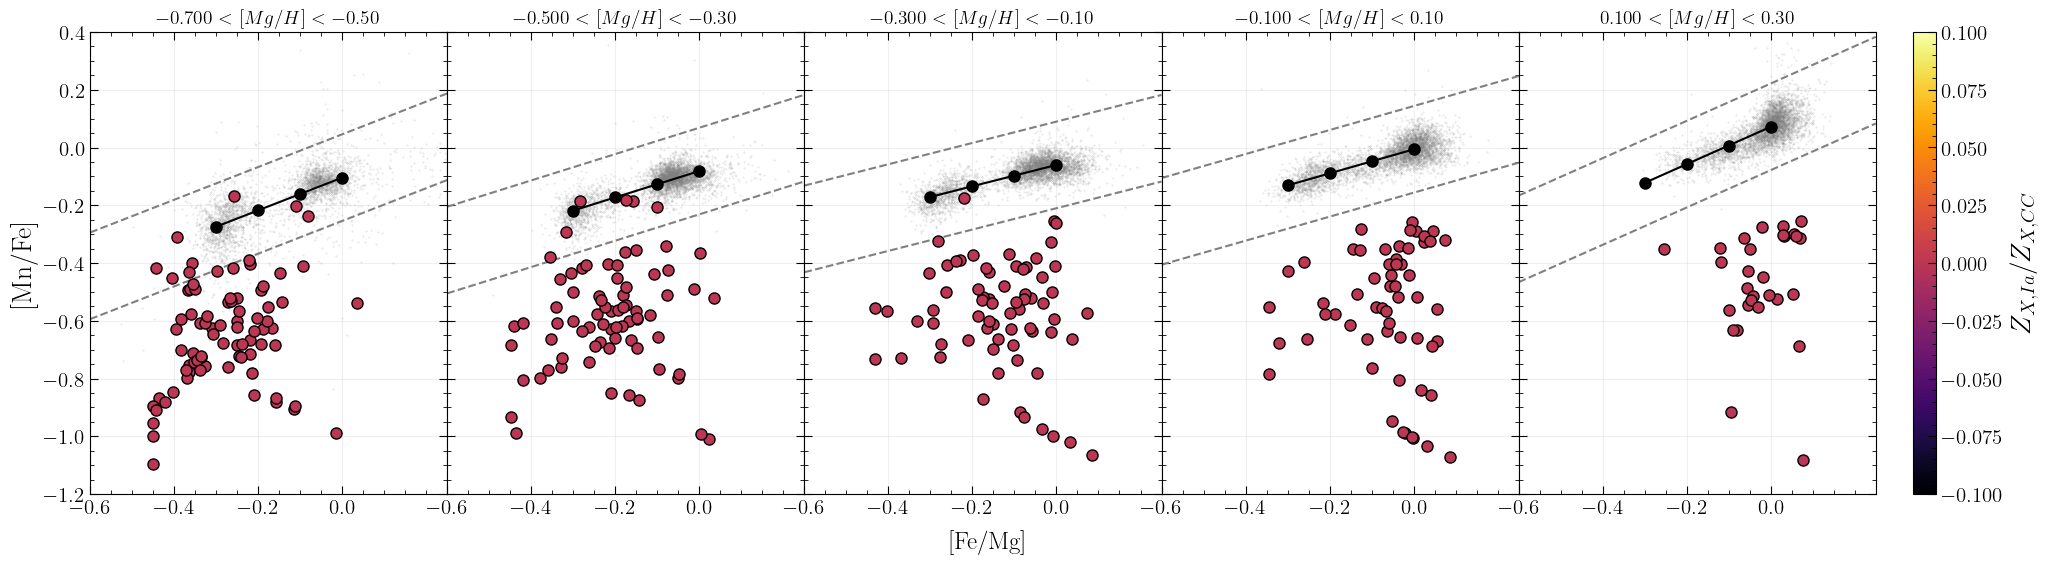

In [31]:
fig_x = 24
fig_y = 6
gals_list = random_gals_list

fig, axes = plt.subplots(1, 5, figsize=(fig_x, fig_y), sharex=True, sharey=True)
axes = axes.flatten()

gals_endpoints = find_endpoints(gals_list, mg_h_big_bin_centers)

for i, ax in enumerate(axes):
    downsampled_data = downsample(data[data['MG_H_big_bin'] == i], 5000)
    ax.scatter(downsampled_data['FE_MG'], downsampled_data['MN_FE'], s=0.1, color='gray', alpha=0.3)

    y_centers = slopes_mn_fe[i] * fe_mg_bin_centers + intercepts_mn_fe[i]
    y_lower = slopes_mn_fe[i] * np.linspace(-0.6, 0.25, 100) + intercepts_mn_fe[i] - 0.15
    y_upper = slopes_mn_fe[i] * np.linspace(-0.6, 0.25, 100) + intercepts_mn_fe[i] + 0.15
    ax.plot(fe_mg_bin_centers, y_centers, '-o', color='black', ms=8, zorder=10)

    ax.plot(np.linspace(-0.6, 0.25, 100), y_lower, color = 'gray', linestyle = '--')
    ax.plot(np.linspace(-0.6, 0.25, 100), y_upper, color = 'gray', linestyle = '--')

    idxs = gals_endpoints[i]

    for k, (gal, idx) in enumerate(zip(gals_list, idxs)):
        if idx != -1: 
            fe_mg = gal.Fe_Mg[idx]
            mn_fe = gal.Mn_Fe[idx]
            
            # --- NEW: Get dynamic color from the ratio at this specific index ---
            ratio_val = all_ratios[k][idx]
            current_color = cmap(norm(ratio_val))

            ax.plot(fe_mg, mn_fe, marker='o', color=current_color, linewidth=0,
                    markeredgecolor='black', markersize=8, zorder=11)

    if i == 0:
        ax.set_ylabel('[Mn/Fe]')
    
    ax.set_title(
        rf'${mg_h_big_bin_edges[i]:.3f} < [Mg/H] < {mg_h_big_bin_edges[i+1]:.2f}$',
        fontsize=14
    )
    ax.set_xticks(np.arange(-0.6, 0.2, 0.2))
    ax.grid(True, alpha=0.2)
    ax.set_xlim(-0.60, 0.25)
    ax.set_ylim(-1.2, 0.40)

fig.supxlabel('[Fe/Mg]')
fig.subplots_adjust(wspace=0)

# --- NEW: Update colorbar ---
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([]) 
cbar = fig.colorbar(sm, ax=axes, fraction=0.02, pad=0.02)
cbar.set_label(r'$Z_{X, Ia} / Z_{X, CC}$', fontsize=20)

plt.show()

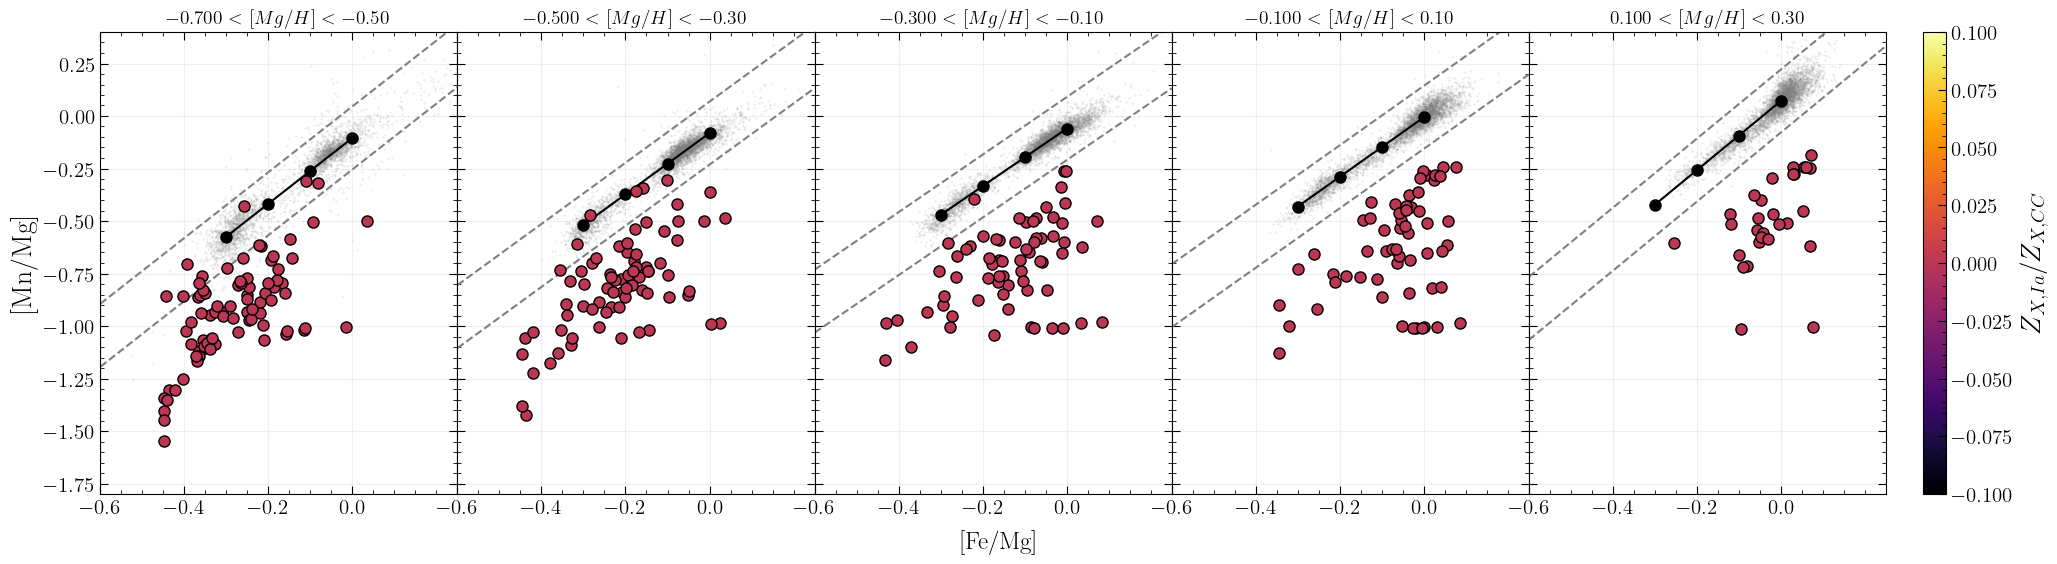

In [32]:
fig_x = 24
fig_y = 6
gals_list = random_gals_list

fig, axes = plt.subplots(1, 5, figsize=(fig_x, fig_y), sharex=True, sharey=True)
axes = axes.flatten()

gals_endpoints = find_endpoints(gals_list, mg_h_big_bin_centers)

for i, ax in enumerate(axes):
    downsampled_data = downsample(data[data['MG_H_big_bin'] == i], 5000)
    ax.scatter(downsampled_data['FE_MG'], downsampled_data['MN_MG'], s=0.1, color='gray', alpha=0.3)

    y_centers = slopes_mn_mg[i] * fe_mg_bin_centers + intercepts_mn_mg[i]
    y_lower = slopes_mn_mg[i] * np.linspace(-0.6, 0.25, 100) + intercepts_mn_mg[i] - 0.15
    y_upper = slopes_mn_mg[i] * np.linspace(-0.6, 0.25, 100) + intercepts_mn_mg[i] + 0.15
    ax.plot(fe_mg_bin_centers, y_centers, '-o', color='black', ms=8, zorder=10)

    ax.plot(np.linspace(-0.6, 0.25, 100), y_lower, color='gray', linestyle='--')
    ax.plot(np.linspace(-0.6, 0.25, 100), y_upper, color='gray', linestyle='--')

    idxs = gals_endpoints[i]

    for k, (gal, idx) in enumerate(zip(gals_list, idxs)):
        if idx != -1: 
            fe_mg = gal.Fe_Mg[idx]
            mn_mg = gal.Mn_Mg[idx]
            
            # --- NEW: Get dynamic color from ratio ---
            ratio_val = all_ratios[k][idx]
            current_color = cmap(norm(ratio_val))

            ax.plot(fe_mg, mn_mg, marker='o', color=current_color, linewidth=0,
                    markeredgecolor='black', markersize=8, zorder=11)

    if i == 0:
        ax.set_ylabel('[Mn/Mg]')
    
    ax.set_title(
        rf'${mg_h_big_bin_edges[i]:.3f} < [Mg/H] < {mg_h_big_bin_edges[i+1]:.2f}$',
        fontsize=14
    )
    ax.set_xticks(np.arange(-0.6, 0.2, 0.2))
    ax.grid(True, alpha=0.2)
    ax.set_xlim(-0.60, 0.25)
    ax.set_ylim(-1.8, 0.40) 

fig.supxlabel('[Fe/Mg]')
fig.subplots_adjust(wspace=0)

# --- NEW: Add ratio colorbar (replacing the discrete legend) ---
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([]) 
cbar = fig.colorbar(sm, ax=axes, fraction=0.02, pad=0.02)
cbar.set_label(r'$Z_{X, Ia} / Z_{X, CC}$', fontsize=20)

plt.show()